In [25]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time

(np.float64(-0.5), np.float64(2499.5), np.float64(2499.5), np.float64(-0.5))

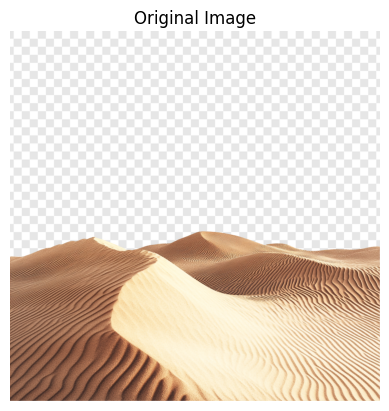

In [26]:
img = cv2.imread("image.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

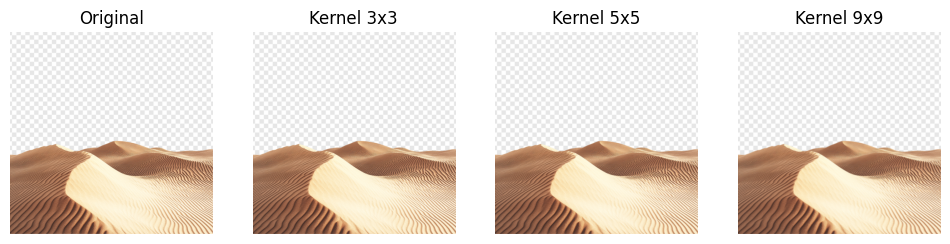

In [27]:
blur3 = cv2.blur(img,(3,3))
blur5 = cv2.blur(img,(5,5))
blur9 = cv2.blur(img,(9,9))

plt.figure(figsize=(12,4))

plt.subplot(1,4,1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(blur3)
plt.title("Kernel 3x3")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(blur5)
plt.title("Kernel 5x5")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(blur9)
plt.title("Kernel 9x9")
plt.axis("off")

plt.show()

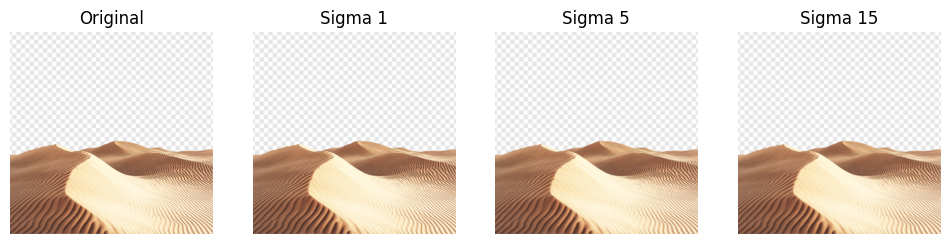

In [28]:
gauss1 = cv2.GaussianBlur(img,(9,9),1)
gauss5 = cv2.GaussianBlur(img,(9,9),5)
gauss15 = cv2.GaussianBlur(img,(9,9),15)

plt.figure(figsize=(12,4))

plt.subplot(1,4,1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(gauss1)
plt.title("Sigma 1")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(gauss5)
plt.title("Sigma 5")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(gauss15)
plt.title("Sigma 15")
plt.axis("off")

plt.show()

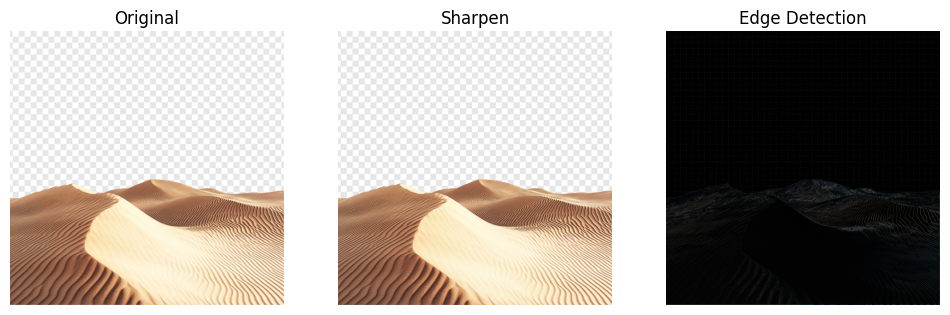

In [29]:
sharpen_kernel = np.array([
    [0,-1,0],
    [-1,5,-1],
    [0,-1,0]
])

edge_kernel = np.array([
    [-1,-1,-1],
    [-1,8,-1],
    [-1,-1,-1]
])

sharpen_img = cv2.filter2D(img,-1,sharpen_kernel)
edge_img = cv2.filter2D(img,-1,edge_kernel)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(sharpen_img)
plt.title("Sharpen")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(edge_img)
plt.title("Edge Detection")
plt.axis("off")

plt.show()

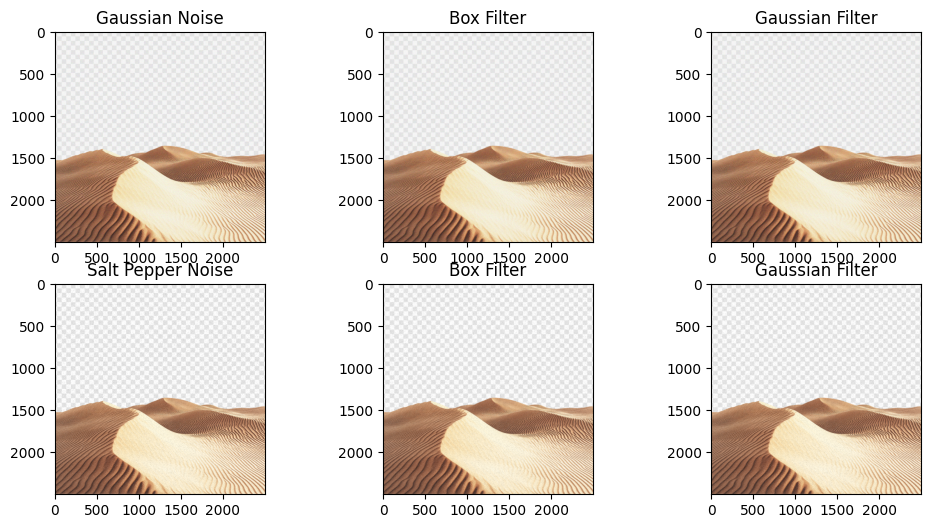

In [30]:
mean = 0
sigma = 25

gaussian_noise = np.random.normal(mean,sigma,img.shape)
noisy_gaussian = np.clip(img + gaussian_noise,0,255).astype(np.uint8)

noisy_sp = img.copy()
prob = 0.02

rnd = np.random.rand(*img.shape[:2])
noisy_sp[rnd < prob] = 0
noisy_sp[rnd > 1-prob] = 255

box_gauss = cv2.blur(noisy_gaussian,(5,5))
gauss_gauss = cv2.GaussianBlur(noisy_gaussian,(5,5),1)

box_sp = cv2.blur(noisy_sp,(5,5))
gauss_sp = cv2.GaussianBlur(noisy_sp,(5,5),1)

plt.figure(figsize=(12,6))

plt.subplot(2,3,1)
plt.imshow(noisy_gaussian)
plt.title("Gaussian Noise")

plt.subplot(2,3,2)
plt.imshow(box_gauss)
plt.title("Box Filter")

plt.subplot(2,3,3)
plt.imshow(gauss_gauss)
plt.title("Gaussian Filter")

plt.subplot(2,3,4)
plt.imshow(noisy_sp)
plt.title("Salt Pepper Noise")

plt.subplot(2,3,5)
plt.imshow(box_sp)
plt.title("Box Filter")

plt.subplot(2,3,6)
plt.imshow(gauss_sp)
plt.title("Gaussian Filter")

plt.show()

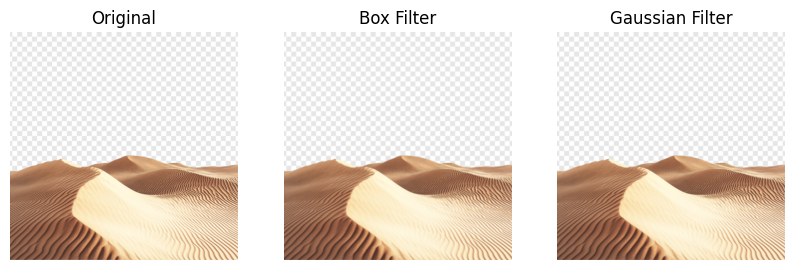

In [31]:
box = cv2.blur(img,(9,9))
gauss = cv2.GaussianBlur(img,(9,9),2)

plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(box)
plt.title("Box Filter")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(gauss)
plt.title("Gaussian Filter")
plt.axis("off")

plt.show()

In [32]:
runs = 50

kernel = np.ones((5,5))/25

start = time.time()
for i in range(runs):
    cv2.filter2D(img,-1,kernel)

filter_time = (time.time()-start)/runs

start = time.time()
for i in range(runs):
    cv2.GaussianBlur(img,(5,5),1)

gaussian_time = (time.time()-start)/runs

print("Average filter2D time:",filter_time)
print("Average GaussianBlur time:",gaussian_time)

Average filter2D time: 0.06312918663024902
Average GaussianBlur time: 0.01597604751586914


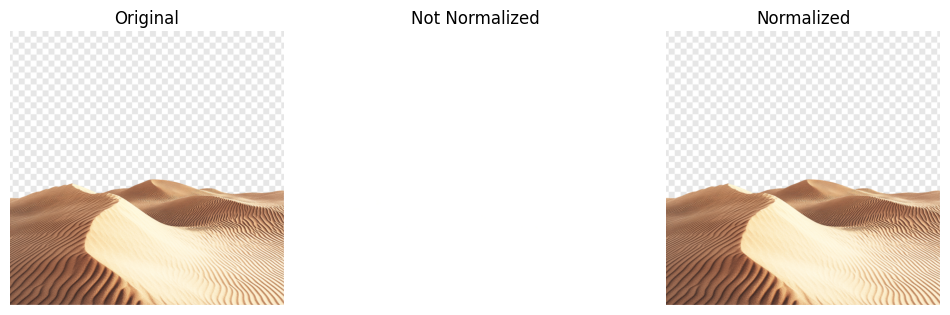

In [33]:
kernel_bad = np.ones((3,3))

result_bad = cv2.filter2D(img,-1,kernel_bad)

kernel_good = kernel_bad / np.sum(kernel_bad)

result_good = cv2.filter2D(img,-1,kernel_good)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(result_bad)
plt.title("Not Normalized")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(result_good)
plt.title("Normalized")
plt.axis("off")

plt.show()

Choose filter:
1 - Uniform Filter
2 - Gaussian Filter
Enter choice: 2
Enter kernel size (odd number): 51
Enter sigma value: 30


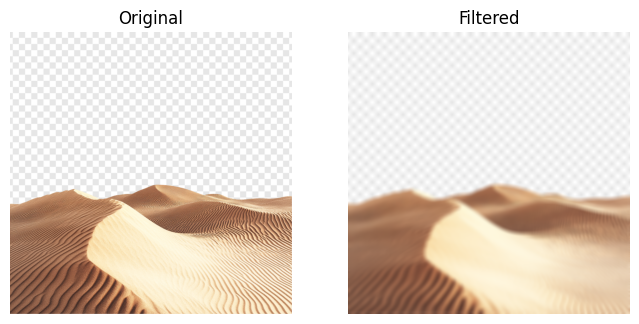

In [34]:
def apply_filter():

    print("Choose filter:")
    print("1 - Uniform Filter")
    print("2 - Gaussian Filter")

    choice = int(input("Enter choice: "))
    k = int(input("Enter kernel size (odd number): "))

    if choice == 1:
        result = cv2.blur(img,(k,k))

    elif choice == 2:
        sigma = float(input("Enter sigma value: "))
        result = cv2.GaussianBlur(img,(k,k),sigma)

    else:
        print("Invalid choice")
        return

    plt.figure(figsize=(8,4))

    plt.subplot(1,2,1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(result)
    plt.title("Filtered")
    plt.axis("off")

    plt.show()


apply_filter()